# K-Means Algorithm

## Library Imports

In [24]:
import numpy as np
import matplotlib.pyplot as plt

## Class Definition

In [25]:
class kmeans:
  def __init__(self, k=3, max_iter=1000, tol=1e-4, random_state=None):
    self.k = k
    self.max_iter = max_iter
    self.tol = tol
    self.random_state = random_state
    self.centroids = None
    self.labels = None
    self.n_iters = 0  #No of iterations until convergence

  # Initialize the centroids
  def _init_random(self,X):
    rng = np.random.default_rng(self.random_state)
    indices = rng.choice(len(X), size=self.k, replace=False)
    return X[indices].copy()

  def _assign_labels(self,X):
    distances = np.linalg.norm(X[:,np.newaxis] - self.centroids, axis=2)
    return np.argmin(distances, axis=1)

  def _update_centroids(self, X, labels):
    new_centroids = np.zeros_like(self.centroids)
    for r in range(self.k):
      members = X[labels==r]
      if len(members)==0:
        new_centroids[r] = self.centroids[r]
      else:
        new_centroids[r] = members.mean(axis=0)
    return new_centroids

  def fit(self, X):
    X = np.array(X, dtype=float)
    # initialize centroids
    self.centroids = self._init_random(X)
    converged = False

    for i in range(self.max_iter):
      labels = self._assign_labels(X)    # assign data point closest to
      new_centroids = self._update_centroids(X, labels)   # update centroid with the mean of all members in the cluster
      shift = np.linalg.norm(new_centroids - self.centroids)    # distance between new and old centroids
      self.centroids = new_centroids

      # if the shift of new centroid is less than the tolerance then convergence is achieved
      if shift < self.tol:
        converged = True
        break

    if converged:
      self.n_iters = i+1
    else:
      self.n_iters = self.max_iter
    self.labels = labels # Store labels after fit to be accessible for plotting
    return self

  def plot_clusters(self, X, labels, centroids, title="K Means Clustering"):
    k = len(centroids)
    plt.figure(figsize=(7,5))
    for c in range(k):
      mask = (labels==c)
      # x and y coordinates for cluster 0 points
      plt.scatter(X[mask,0], X[mask,1], label=f"Cluster {c}")
    plt.scatter(centroids[:,0], centroids[:,1], color="black", marker="x", label="Centroids")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

  def compute_inertia(self, X):
    distances = np.linalg.norm(X[:,np.newaxis] - self.centroids, axis=2)
    square = np.square(distances)
    return np.sum(square)

## Creating Data and Training

Inertia: 215850.42748623886
Converged in 5 iterations.



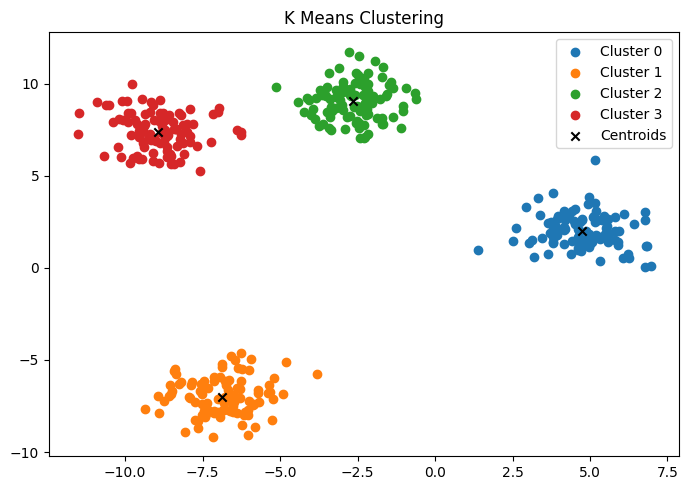

In [26]:
from sklearn.datasets import make_blobs

X,y = make_blobs(n_samples=400, centers=4, random_state=42)
km = kmeans(k=4, random_state=42)
km.fit(X)

inertia = km.compute_inertia(X)
print(f"Inertia: {inertia}")

print(f"Converged in {km.n_iters} iterations.\n")

km.plot_clusters(X, km.labels, km.centroids)
